In [ ]:
import os
import requests
from bs4 import BeautifulSoup
import h5py
import numpy as np

BASE_URL = 'https://www.star.nesdis.noaa.gov/pub/socd1/ecn/data/viirs/rrs672/daily/se/'
DOWNLOAD_DIR = r"Z:\viirs\data_totalsediment"
os.makedirs(DOWNLOAD_DIR, exist_ok=True)

session = requests.Session()
session.headers.update({"User-Agent": "Mozilla/5.0"})

print("Scraping file directory from NOAA server...")
response = session.get(BASE_URL, timeout=30)
soup = BeautifulSoup(response.text, 'html.parser')
nc4_urls = [requests.compat.urljoin(BASE_URL, a['href']) for a in soup.find_all('a', href=True) if a['href'].endswith('.nc4')]
print(f"Total files available on server: {len(nc4_urls)}")

start = 3300
valid_files = []

# Phase 1: Download Subset safely
for idx, url in enumerate(nc4_urls[start:]):
    filename = os.path.basename(url)
    local_nc = os.path.join(DOWNLOAD_DIR, filename)
    temp_nc = local_nc + ".part"
    
    if not os.path.exists(local_nc):
        print(f"Downloading [{start+idx+1}/{len(nc4_urls)}]: {filename}")
        try:
            with session.get(url, timeout=(10, 60), stream=True) as r:
                r.raise_for_status()
                with open(temp_nc, 'wb') as f:
                    for chunk in r.iter_content(chunk_size=1024 * 1024):
                        if chunk: f.write(chunk)
            os.rename(temp_nc, local_nc)
            valid_files.append(local_nc)
        except Exception as e:
            print(f"Skipping {filename} due to download error: {e}")
            if os.path.exists(temp_nc): os.remove(temp_nc)
    else:
        valid_files.append(local_nc)



H5PY DATA EXTRACTION
Successfully read: VRSUCW_2024090_DAILY_SNPP_RRS672_SE_750M.nc4
 -> Rrs_671 Array Shape: (1, 1, 1560, 1080)
 -> Valid Data Min: 0.0000, Max: 6550.0000
Successfully read: VRSUCW_2024091_DAILY_SNPP_RRS672_SE_750M.nc4
 -> Rrs_671 Array Shape: (1, 1, 1560, 1080)
 -> Valid Data Min: 0.0000, Max: 4571.0000
Successfully read: VRSUCW_2024092_DAILY_SNPP_RRS672_SE_750M.nc4
 -> Rrs_671 Array Shape: (1, 1, 1560, 1080)
 -> Valid Data Min: 0.0000, Max: 10143.0000
Successfully read: VRSUCW_2024093_DAILY_SNPP_RRS672_SE_750M.nc4
 -> Rrs_671 Array Shape: (1, 1, 1560, 1080)
 -> Valid Data Min: 0.0000, Max: 9922.0000
Successfully read: VRSUCW_2024094_DAILY_SNPP_RRS672_SE_750M.nc4
 -> Rrs_671 Array Shape: (1, 1, 1560, 1080)
 -> Valid Data Min: 0.0000, Max: 2593.0000
Successfully read: VRSUCW_2024095_DAILY_SNPP_RRS672_SE_750M.nc4
 -> Rrs_671 Array Shape: (1, 1, 1560, 1080)
 -> Valid Data Min: 0.0000, Max: 3452.0000
Successfully read: VRSUCW_2024096_DAILY_SNPP_RRS672_SE_750M.nc4
 -> Rrs

c:\Users\lwlav\miniconda3\envs\viirstutorial\lib\site-packages\ipykernel_launcher.py:64: RuntimeWarning: All-NaN slice encountered


Successfully read: VRSUCW_2024120_DAILY_SNPP_RRS672_SE_750M.nc4
 -> Rrs_671 Array Shape: (1, 1, 1560, 1080)
 -> Valid Data Min: 0.0000, Max: 4718.0000
Successfully read: VRSUCW_2024121_DAILY_SNPP_RRS672_SE_750M.nc4
 -> Rrs_671 Array Shape: (1, 1, 1560, 1080)
 -> Valid Data Min: 0.0000, Max: 1727.0000
Successfully read: VRSUCW_2024122_DAILY_SNPP_RRS672_SE_750M.nc4
 -> Rrs_671 Array Shape: (1, 1, 1560, 1080)
 -> Valid Data Min: 0.0000, Max: 6775.0000
Successfully read: VRSUCW_2024123_DAILY_SNPP_RRS672_SE_750M.nc4
 -> Rrs_671 Array Shape: (1, 1, 1560, 1080)
 -> Valid Data Min: 0.0000, Max: 3547.0000
Successfully read: VRSUCW_2024124_DAILY_SNPP_RRS672_SE_750M.nc4
 -> Rrs_671 Array Shape: (1, 1, 1560, 1080)
 -> Valid Data Min: 0.0000, Max: 8732.0000
Successfully read: VRSUCW_2024125_DAILY_SNPP_RRS672_SE_750M.nc4
 -> Rrs_671 Array Shape: (1, 1, 1560, 1080)
 -> Valid Data Min: 0.0000, Max: 8584.0000
Successfully read: VRSUCW_2024126_DAILY_SNPP_RRS672_SE_750M.nc4
 -> Rrs_671 Array Shape: (1, 1

KeyboardInterrupt: 

In [7]:
import glob
import os
import imageio.v2 as imageio  # Using v2 to avoid deprecation warnings

# 1. Gather all the saved frames in order
# (Using sorted ensures they stitch together chronologically)
frame_files = sorted(glob.glob(os.path.join(FRAME_DIR, "viirs_sedimentindex_*.png")))

# 2. Read the images into a list
images = []
for filename in frame_files:
    images.append(imageio.imread(filename))

# 3. Save as a GIF
gif_path = os.path.join(r"Z:\viirs", "viirs_sediment_animation.gif")

# duration=500 means each frame displays for 500 milliseconds (0.5 seconds)
# loop=0 means the GIF will loop infinitely
imageio.mimsave(gif_path, images, duration=500, loop=0)

print(f"GIF successfully created at: {gif_path}")

GIF successfully created at: Z:\viirs\viirs_sediment_animation.gif


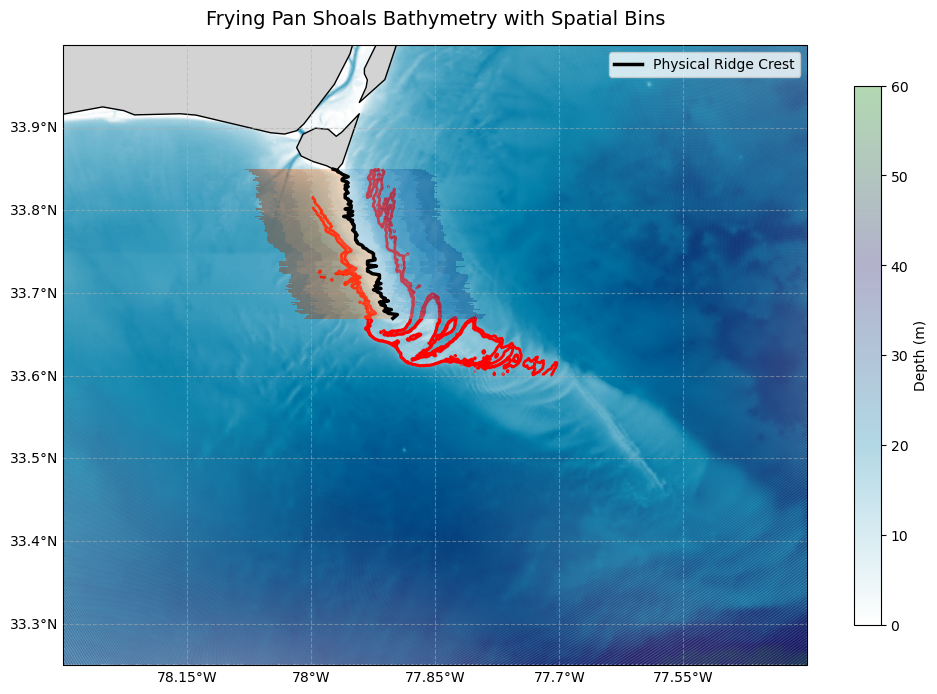

In [8]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from scipy.io import loadmat
from scipy.interpolate import griddata

data = loadmat(r"Z:\viirs\FPS_bathy\FPS_bathy.mat")
depth = data["z"]
bathy_x = data["G"][0][0][0]
bathy_y = data["G"][0][0][1]

utm18 = ccrs.UTM(zone=18)
latlon = ccrs.PlateCarree()

transformed_coords = latlon.transform_points(utm18, bathy_x, bathy_y)
bathy_lon = transformed_coords[..., 0]
bathy_lat = transformed_coords[..., 1]

flat_lon = bathy_lon.flatten()
flat_lat = bathy_lat.flatten()
flat_depth = depth.flatten()

valid_mask = np.isfinite(flat_lon) & np.isfinite(flat_lat) & np.isfinite(flat_depth)
clean_lon = flat_lon[valid_mask]
clean_lat = flat_lat[valid_mask]
clean_depth = flat_depth[valid_mask]

# Define exact extents
lat_min, lat_max = 33.25, 34.0
lon_min, lon_max = -78.3, -77.4
shoals_lat_min, shoals_lat_max = 33.6, 33.85
shoals_lon_min, shoals_lon_max = -78, -77.7
main_shoals_min, main_shoals_max = 33.668, 33.85  # Extent for centerline/bins

square_mask = (
    (clean_lat >= lat_min) & (clean_lat <= lat_max) & 
    (clean_lon >= lon_min) & (clean_lon <= lon_max)
)

trimmed_lon = clean_lon[square_mask]
trimmed_lat = clean_lat[square_mask]
trimmed_depth = clean_depth[square_mask]

grid_lon = np.linspace(lon_min, lon_max, 500)
grid_lat = np.linspace(lat_min, lat_max, 500)
lon_mesh, lat_mesh = np.meshgrid(grid_lon, grid_lat)

grid_depth = griddata(
    (trimmed_lon, trimmed_lat), trimmed_depth, 
    (lon_mesh, lat_mesh), method='linear'
)

outside_shoal_mask = (
    (lon_mesh < shoals_lon_min) | (lon_mesh > shoals_lon_max) |
    (lat_mesh < shoals_lat_min) | (lat_mesh > shoals_lat_max)
)
grid_depth[outside_shoal_mask] = np.nan

peak_lon = []
peak_lat = []
dims = np.shape(grid_depth)
for i in np.arange(dims[0]):
    lat = lat_mesh[i,0]
    if lat <= main_shoals_min or lat >= main_shoals_max:
        continue
    # Find the shallowest point in the row
    row_depth = grid_depth[i,:]
    valid_idx = np.isfinite(row_depth)
    if not np.any(valid_idx):
        continue
    peakid = np.nanargmin(row_depth)
    peak_lon.append(lon_mesh[i, peakid])
    peak_lat.append(lat)

peak_lon = np.array(peak_lon)
peak_lat = np.array(peak_lat)

fig, ax = plt.subplots(figsize=(12, 10), subplot_kw={"projection": ccrs.PlateCarree()})

land_10m = cfeature.NaturalEarthFeature(
    category="physical", name="land", scale="10m",
    edgecolor="black", facecolor="lightgray",
)
ax.add_feature(land_10m, zorder=2)

# Plot raw bathymetry points
sc = ax.scatter(
    trimmed_lon, trimmed_lat, c=trimmed_depth,
    transform=ccrs.PlateCarree(), cmap="ocean_r", # Flipped so shallow is lighter
    s=1, zorder=1, vmin=0, vmax=60, alpha=0.3
)
plt.colorbar(sc, ax=ax, label="Depth (m)", shrink=0.7)

# Add the 10m isobath contour
ax.contour(
    lon_mesh, lat_mesh, grid_depth, levels=[10.0, 11.0], 
    colors='red', linewidths=2, transform=ccrs.PlateCarree(), zorder=4
)

# Plot Centerline
ax.plot(
    peak_lon, peak_lat, color='black', linewidth=2.5, linestyle='-',
    transform=ccrs.PlateCarree(), zorder=6, label='Physical Ridge Crest'
)

# Interpolate centerline onto our full meshgrid just like the satellite script
sort_idx = np.argsort(peak_lat)
interp_centerline_lon = np.interp(lat_mesh, peak_lat[sort_idx], peak_lon[sort_idx])

# Calculate miles from crest
deg_per_mile_lon = 0.0215 
miles_from_crest = np.abs(lon_mesh - interp_centerline_lon) / deg_per_mile_lon

# Mask out areas north/south of our analysis bounds
analysis_mask = (lat_mesh >= main_shoals_min) & (lat_mesh <= main_shoals_max)
miles_from_crest = np.where(analysis_mask, miles_from_crest, np.nan)

# Create boolean grids for East and West
east_mask = lon_mesh > interp_centerline_lon
west_mask = lon_mesh <= interp_centerline_lon

bin_edges = [0, 1, 2, 3, 4, 5]

# Define two custom colormaps for the bins (Blues for East, Oranges for West)
east_colors = plt.cm.Blues(np.linspace(0.4, 0.9, len(bin_edges)-1))
west_colors = plt.cm.Oranges(np.linspace(0.4, 0.9, len(bin_edges)-1))

for i in range(len(bin_edges) - 1):
    low_dist = bin_edges[i]
    high_dist = bin_edges[i+1]
    
    # Distance condition
    dist_mask = (miles_from_crest >= low_dist) & (miles_from_crest < high_dist)
    
    # Isolate East and West bins
    current_east = np.where(dist_mask & east_mask, 1, np.nan)
    current_west = np.where(dist_mask & west_mask, 1, np.nan)
    
    # Create solid color maps for plotting
    cmap_east = mcolors.ListedColormap([east_colors[i]])
    cmap_west = mcolors.ListedColormap([west_colors[i]])
    
    # Plot East bins
    ax.pcolormesh(
        lon_mesh, lat_mesh, current_east,
        transform=ccrs.PlateCarree(), cmap=cmap_east, alpha=0.4, zorder=5
    )
    # Plot West bins
    ax.pcolormesh(
        lon_mesh, lat_mesh, current_west,
        transform=ccrs.PlateCarree(), cmap=cmap_west, alpha=0.4, zorder=5
    )

plt.title("Frying Pan Shoals Bathymetry with Spatial Bins", fontsize=14, pad=15)
ax.legend(loc='upper right')

gl = ax.gridlines(draw_labels=True, linestyle="--", alpha=0.5, zorder=3)
gl.top_labels = False
gl.right_labels = False

ax.set_extent([lon_min, lon_max, lat_min, lat_max], crs=ccrs.PlateCarree())
plt.show()

# Save out trimmed bathy grid
output_npz_path = r"Z:\viirs\FPS_bathy\Trimmed_grid"
np.savez_compressed(
    output_npz_path, lon=lon_mesh, lat=lat_mesh, depth=grid_depth
)

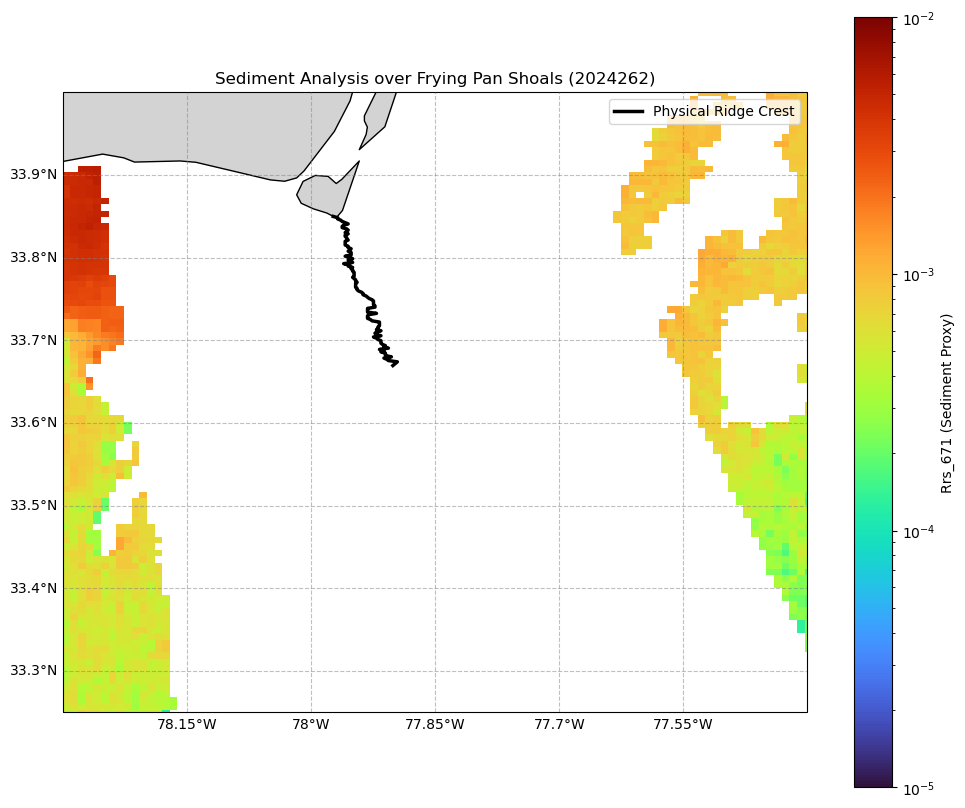

Saved: Z:\viirs\frames_totalsediment\viirs_sedimentindex_2024262.png


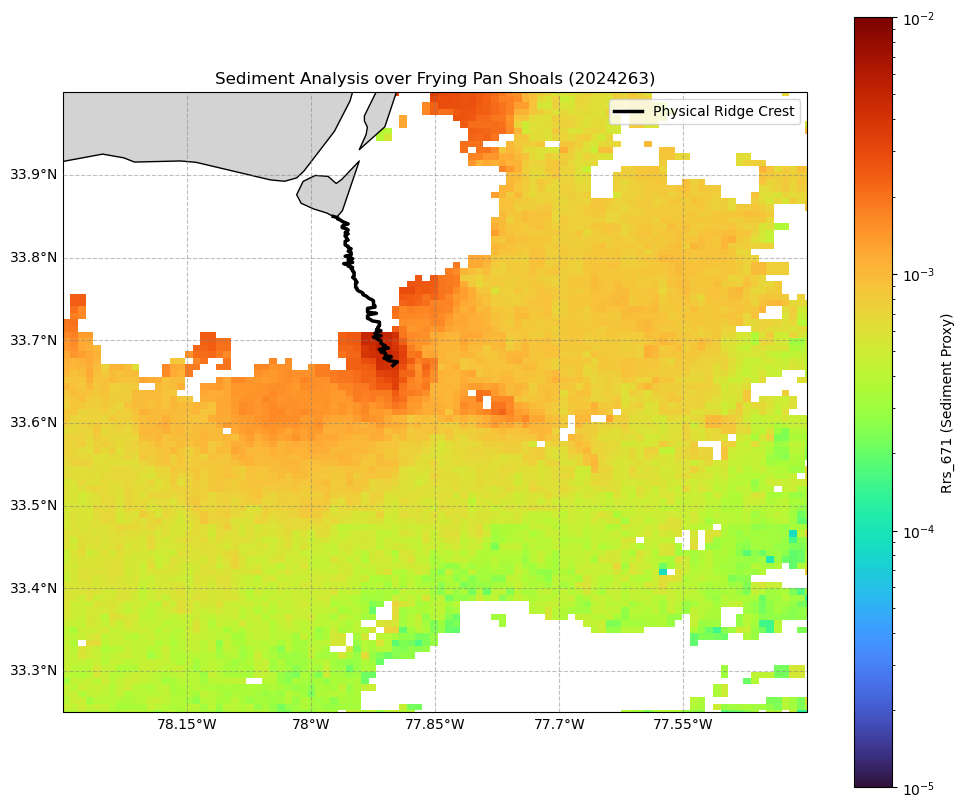

Saved: Z:\viirs\frames_totalsediment\viirs_sedimentindex_2024263.png


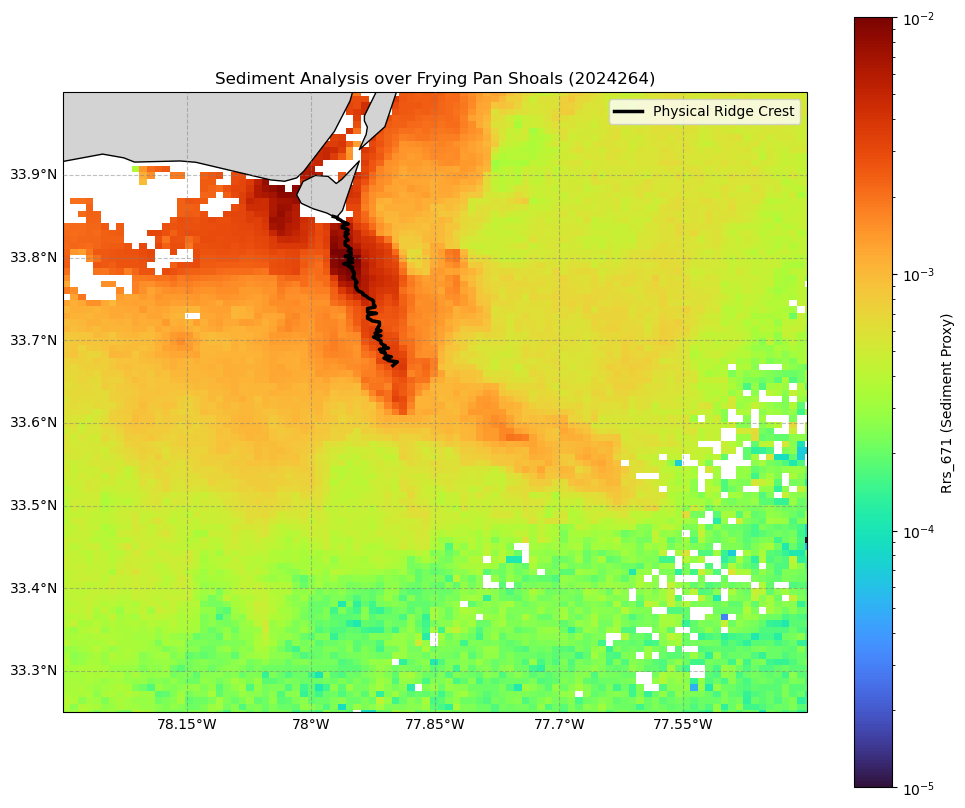

Saved: Z:\viirs\frames_totalsediment\viirs_sedimentindex_2024264.png


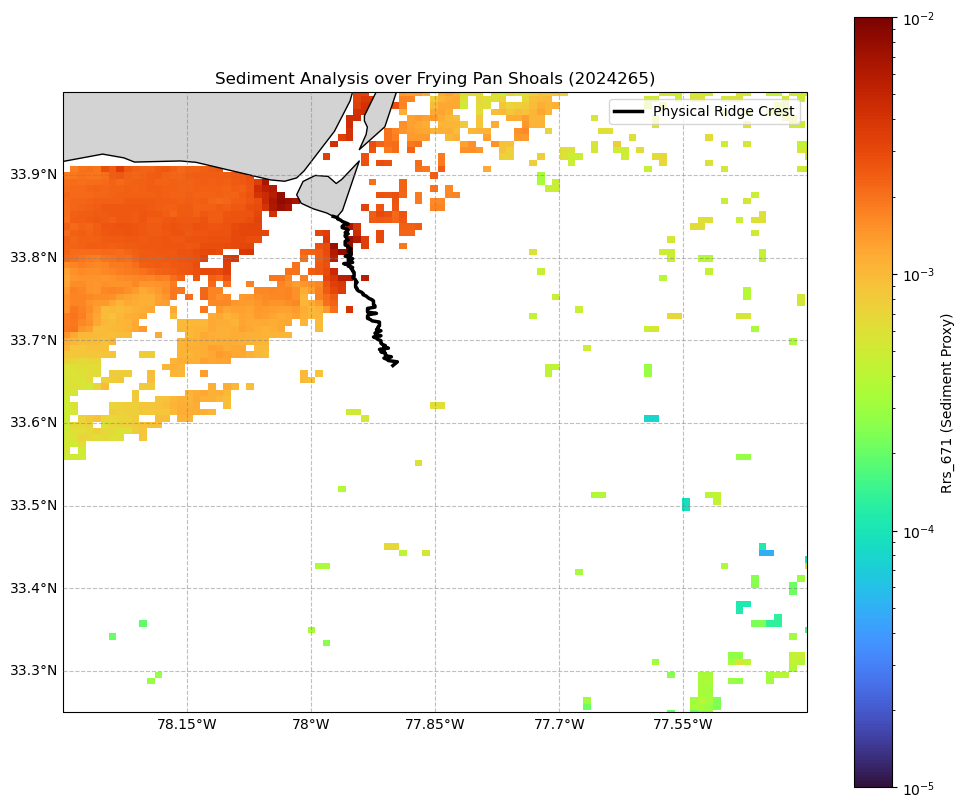

Saved: Z:\viirs\frames_totalsediment\viirs_sedimentindex_2024265.png


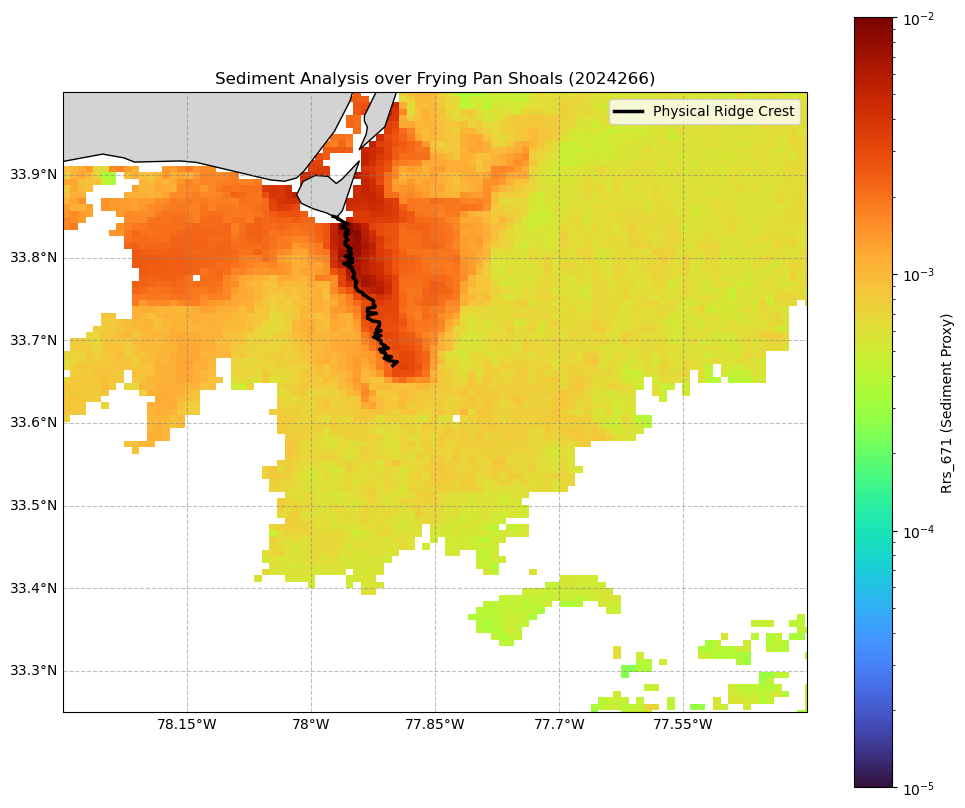

Saved: Z:\viirs\frames_totalsediment\viirs_sedimentindex_2024266.png


In [11]:
# Code to analyze data on which days saw larger plumes on south side of shoal vs east
# First test one day
import os
import glob
import h5py
import matplotlib.pyplot as plt
import cartopy.feature as cfeature
import matplotlib.colors as colors  

DATA_DIR = r"Z:\viirs\data_totalsediment" 
FRAME_DIR = r"Z:\viirs\frames_totalsediment"
os.makedirs(FRAME_DIR, exist_ok=True)

# Grab the first 3 HDF5/NC4 files to loop through multiple days
#Start on 202490, 2024262 is TC8ish, 165-175 is interesting
h5_files = sorted(glob.glob(os.path.join(DATA_DIR, "*.nc4")))[140:145]

#Edges of main shoals so centerline isn't past C0
main_shoals_min, main_shoals_max = 33.668,33.85

#Get bathy data
data = np.load(r"Z:\viirs\FPS_bathy\Trimmed_grid.npz")
dims = np.shape(data['depth'])
#Make nans super deep so doesn't mess with peaks
depth_matrix = np.copy(data['depth'])
depth_matrix[~np.isfinite(depth_matrix)] = 999

peak_lon = []
peak_lat = []
#Make south side and east side shoal masks
for i in np.arange(dims[0]):
    lat = data['lat'][i,0]
    if lat <= shoals_lat_min or lat >= shoals_lat_max: #Get only FPS peaks
        continue
    if lat <= main_shoals_min or lat >= main_shoals_max:
        continue
    peakid = np.argmin(depth_matrix[i,:]) #Location of peak depth
    #Get peak and save location
    peak_lon.append(data['lon'][i,peakid])
    peak_lat.append(lat)
peak_lon = np.array(peak_lon)
peak_lat = np.array(peak_lat)

#Create east and south mask 1 mile = 0.0215 degrees west,1 mile =  0.0145 degrees north


for file_path in h5_files:
    filename = os.path.basename(file_path)
    path = os.path.normpath(file_path)
    
    # Extract date from filepath string
    date_str = path.split(os.sep)[3]
    date_str = date_str.split("_")[1]
    save_file = os.path.join(FRAME_DIR, f'viirs_sedimentindex_{date_str}.png')
    
    with h5py.File(file_path, 'r') as f:
        # Standard NASA HDF-EOS5 path for 1km data fields
        sat_lat = f['lat'][()].squeeze()
        sat_lon = f['lon'][()].squeeze()
        
        # Renamed to time_val to prevent overwriting your date_str
        time_val = f['time'][()].squeeze() 
        kd_data = f['Rrs_671'][()]
        
        # Extract metadata attributes (like scale factors or fill values) if needed
        # Grab the fill value, scale factor, and offset from the metadata attributes
        fill_value = f['Rrs_671'].attrs.get('_FillValue', [-32768])[0]
        scale_factor = f['Rrs_671'].attrs.get('scale_factor', [1.0])[0]
        add_offset = f['Rrs_671'].attrs.get('add_offset', [0.0])[0]
        
        # Convert raw integers to float64 so we don't get truncation errors
        kd_data = kd_data.astype(np.float64)        
        
        kd_data = np.where(kd_data == fill_value, np.nan, kd_data)
        kd_data = kd_data.squeeze()
        # Apply scale and offset values to get true data
        kd_data = (kd_data * scale_factor) + add_offset
    

        # mask out all data that is not over the main shoals, this will exclude plumes headed strait south
        spatial_mask = (sat_lat >= main_shoals_min) & (sat_lat <= main_shoals_max)
        sat_lat_clipped = sat_lat[spatial_mask]
        sat_lon_clipped = sat_lon[spatial_mask]
        sat_val_clipped = kd_data[spatial_mask]
       
        #Use interpolation to find wherre the shoals center line is in the sattelite lat and lon grid
        sort_idx = np.argsort(peak_lat) #Returns indices of a sorted peak lat, just for safety
        interp_centerline_lon = np.interp(sat_lat_clipped, peak_lat[sort_idx], peak_lon[sort_idx])

        #Get mask containing data to east and west of shoal
        east_mask = sat_lon_clipped > interp_centerline_lon
        west_mask = sat_lon_clipped <= interp_centerline_lon

        #Now create multiple bins according to length of each mile
        deg_per_mile_lon = 0.0215 

        # Calculate absolute distance in miles from the physical ridge crest
        miles_from_crest = np.abs(sat_lon_clipped - interp_centerline_lon) / deg_per_mile_lon

        # Define your bin edges (e.g., 0 to 5 miles out, in 1-mile steps)
        bin_edges = [0, 1, 2, 3, 4, 5]

        for i in range(len(bin_edges) - 1):
            low_dist = bin_edges[i]
            high_dist = bin_edges[i+1]
            
            # Distance condition
            dist_mask = (miles_from_crest >= low_dist) & (miles_from_crest < high_dist)
            
            # Combine with side masks to get specific regional bins!
            east_bin = sat_val_clipped[dist_mask & east_mask]
            west_bin = sat_val_clipped[dist_mask & west_mask]
    
        fig, ax = plt.subplots(figsize=(12, 10), subplot_kw={'projection': ccrs.PlateCarree()})
        
        # Set spatial extent (zoom) around Frying Pan Shoals
        ax.set_extent([-78.7, -77.1, 33, 34.2], crs=ccrs.PlateCarree())
        
        # Add high-resolution land and coastline features
        # Use the Natural Earth 10-meter resolution dataset instead
        land_10m = cfeature.NaturalEarthFeature(
            category='physical', 
            name='land', 
            scale='10m',
            edgecolor='black', 
            facecolor='lightgray'
        )
        ax.add_feature(land_10m, zorder=2)
        # Plot the satellite data
        log_norm = colors.LogNorm(vmin=1E-5, vmax=1E-2)
        img = ax.pcolormesh(sat_lon, sat_lat, kd_data, transform=ccrs.PlateCarree(), 
                            cmap='turbo', norm=log_norm, zorder=1)
        plt.colorbar(img, ax=ax, label='Rrs_671 (Sediment Proxy)', pad=0.05)

        # Draw centerline
        ax.plot(
            peak_lon, peak_lat,
            color='black',
            linewidth=2.5,
            linestyle='-',
            transform=ccrs.PlateCarree(),
            zorder=5,
            label='Physical Ridge Crest'
        )

        plt.legend(loc='upper right')
        # Formatting
        ax.legend(loc='upper right')
        plt.title(f'Sediment Analysis over Frying Pan Shoals ({date_str})')
        
        # Add gridlines
        gl = ax.gridlines(draw_labels=True, linestyle='--', alpha=0.5, color='gray', zorder=4)
        gl.top_labels = False
        gl.right_labels = False

        ax.set_extent([lon_min, lon_max, lat_min, lat_max], crs=ccrs.PlateCarree())

        plt.show()

        # Save and close out the figure to free up memory before the next loop iteration
        # plt.savefig(save_file, dpi=300, bbox_inches='tight')
        # plt.close(fig)
        
        print(f"Saved: {save_file}")

In [ ]:
import os
import glob
import h5py
import numpy as np
import pandas as pd
#This took 1 hour to run 
DATA_DIR = r"Z:\viirs\data_totalsediment" 

# Grab the files to loop through multiple days
h5_files = sorted(glob.glob(os.path.join(DATA_DIR, "*.nc4")))[:]

# Edges of main shoals so centerline isn't past C0
main_shoals_min, main_shoals_max = 33.668, 33.85
shoals_lat_min, shoals_lat_max = 33.6, 33.85

#Load in bathy data and remove nans so it doesn't interfere with peak 
data = np.load(r"Z:\viirs\FPS_bathy\Trimmed_grid.npz")
dims = np.shape(data['depth'])

depth_matrix = np.copy(data['depth'])
depth_matrix[~np.isfinite(depth_matrix)] = 999

peak_lon = []
peak_lat = []

# Make south side and east side shoal masks
for i in np.arange(dims[0]):
    lat = data['lat'][i,0]
    if lat <= shoals_lat_min or lat >= shoals_lat_max: 
        continue
    if lat <= main_shoals_min or lat >= main_shoals_max:
        continue
        
    peakid = np.argmin(depth_matrix[i,:]) 
    peak_lon.append(data['lon'][i,peakid])
    peak_lat.append(lat)

peak_lon = np.array(peak_lon)
peak_lat = np.array(peak_lat)

#Find the east and west bins
deg_per_mile_lon = 0.0215 
bin_edges = [0, 1, 2, 3, 4, 5]

# Create nice labels for the rows in CSV (e.g., "0-1 miles", "1-2 miles")
bin_labels = [f"{bin_edges[i]} to {bin_edges[i+1]} miles" for i in range(len(bin_edges) - 1)]

results_dict = {
    'Distance_Bin': bin_labels
}

#loop through days of sattelite data
for file_path in h5_files:
    path = os.path.normpath(file_path)
    
    # Extract date from filepath string
    date_str = path.split(os.sep)[3]
    date_str = date_str.split("_")[1]
    
    with h5py.File(file_path, 'r') as f:
        # Standard NASA HDF-EOS5 path for 1km data fields
        sat_lat = f['lat'][()].squeeze()
        sat_lon = f['lon'][()].squeeze()
        
        kd_data = f['Rrs_671'][()]
        # Extract metadata attributes (like scale factors or fill values) if needed
        # Grab the fill value, scale factor, and offset from the metadata attributes
        fill_value = f['Rrs_671'].attrs.get('_FillValue', [-32768])[0]
        scale_factor = f['Rrs_671'].attrs.get('scale_factor', [1.0])[0]
        add_offset = f['Rrs_671'].attrs.get('add_offset', [0.0])[0]
        
        # Convert raw integers to float64 so we don't get truncation errors
        kd_data = kd_data.astype(np.float64)
        
        # Mask out the missing data using the fill value
        kd_data = np.where(kd_data == fill_value, np.nan, kd_data)
        kd_data = kd_data.squeeze()
        
        # Apply scale and offset values to get true data
        kd_data = (kd_data * scale_factor) + add_offset

        # Mask out all data that is not over the main shoals
        spatial_mask = (sat_lat >= main_shoals_min) & (sat_lat <= main_shoals_max)
        sat_lat_clipped = sat_lat[spatial_mask]
        sat_lon_clipped = sat_lon[spatial_mask]
        sat_val_clipped = kd_data[spatial_mask]
       
        # Use interpolation to find where the shoals center line is
        # np.interp needs ascending x-values, so we sort the latitudes
        sort_idx = np.argsort(peak_lat) 
        interp_centerline_lon = np.interp(sat_lat_clipped, peak_lat[sort_idx], peak_lon[sort_idx])

        # Get mask containing data to east and west of shoal centerline
        east_mask = sat_lon_clipped > interp_centerline_lon
        west_mask = sat_lon_clipped <= interp_centerline_lon

        # Calculate absolute distance in miles from the physical ridge crest
        miles_from_crest = np.abs(sat_lon_clipped - interp_centerline_lon) / deg_per_mile_lon

        day_east_means = []
        day_west_means = []

        # Loop through the bins and extract the data
        for i in range(len(bin_edges) - 1):
            low_dist = bin_edges[i]
            high_dist = bin_edges[i+1]
            
            # Distance condition
            dist_mask = (miles_from_crest >= low_dist) & (miles_from_crest < high_dist)
            
            # Combine with side masks to get specific regional bins
            east_bin = sat_val_clipped[dist_mask & east_mask]
            west_bin = sat_val_clipped[dist_mask & west_mask]
            
            # Calculate the mean sediment proxy for this bin. 
            # Note: Change np.nanmean to np.nansum if want total sum instead of averages.
            east_val = np.nanmean(east_bin) if np.any(~np.isnan(east_bin)) else np.nan
            west_val = np.nanmean(west_bin) if np.any(~np.isnan(west_bin)) else np.nan
            
            day_east_means.append(east_val)
            day_west_means.append(west_val)
            
        # Append this day's results to the master dictionary
        results_dict[f'East_Rrs671_{date_str}'] = day_east_means
        results_dict[f'West_Rrs671_{date_str}'] = day_west_means
        
    print(f"Processed: {date_str}")

#Save data
df = pd.DataFrame(results_dict)

output_csv_path = os.path.join(DATA_DIR, "Shoal_Sediment_Distance_Bins.csv")
df.to_csv(output_csv_path, index=False)

print(f"\nSuccess! Data compiled and saved to {output_csv_path}")

NameError: name 'data' is not defined

In [2]:
import os
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

csv_path = r"Z:\viirs\data_totalsediment\Shoal_Sediment_Distance_Bins.csv"
output_dir = r"Z:\viirs\frames_totalsediment"
os.makedirs(output_dir, exist_ok=True)

df = pd.read_csv(csv_path)

column_names = df.columns
dates_found = set()
for col in column_names:
    match = re.search(r'Rrs671_(\d+)', col)
    if match:
        dates_found.add(match.group(1))
sorted_dates = sorted(list(dates_found))

valid_dates = []
daily_ratios = []

bins = df['Distance_Bin'].tolist()
east_bin_series = {b: [] for b in bins}
west_bin_series = {b: [] for b in bins}

for date in sorted_dates:
    east_col = f'East_Rrs671_{date}'
    west_col = f'West_Rrs671_{date}'
    
    if east_col in df.columns and west_col in df.columns:
        if not (df[east_col].isna().all() and df[west_col].isna().all()):
            valid_dates.append(date)
            
            east_mean = df[east_col].mean()
            west_mean = df[west_col].mean()
            
            if west_mean > 0 and not np.isnan(east_mean) and not np.isnan(west_mean):
                daily_ratios.append(east_mean / west_mean)
                
            for idx, b in enumerate(bins):
                east_bin_series[b].append(df[east_col].iloc[idx])
                west_bin_series[b].append(df[west_col].iloc[idx])

plt.figure(figsize=(10, 6))
plt.hist(daily_ratios, bins=30, color='skyblue', edgecolor='black', alpha=0.7)
plt.axvline(1.0, color='red', linestyle='--', linewidth=2, label='Equal Intensity (Ratio = 1.0)')
plt.title('Distribution of East-to-West Sediment Plume Ratios Across All Days')
plt.xlabel('Plume Intensity Ratio (East Mean / West Mean)')
plt.ylabel('Frequency (Number of Days)')
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()

hist_path = os.path.join(output_dir, 'plume_ratio_histogram.png')
plt.savefig(hist_path, dpi=300)
plt.close()

plot_data = []
positions = []

for idx, b in enumerate(bins):
    clean_east = [v for v in east_bin_series[b] if not np.isnan(v)]
    clean_west = [v for v in west_bin_series[b] if not np.isnan(v)]
    
    plot_data.append(clean_east)
    plot_data.append(clean_west)
    
    positions.extend([idx * 2.5, idx * 2.5 + 0.8])

fig, ax = plt.subplots(figsize=(12, 6))
bp = ax.boxplot(plot_data, positions=positions, widths=0.6, patch_artist=True)

for i, box in enumerate(bp['boxes']):
    if i % 2 == 0:
        box.set_facecolor('#1f77b4')
    else:
        box.set_facecolor('#ff7f0e')

ax.set_xticks([idx * 2.5 + 0.4 for idx in range(len(bins))])
ax.set_xticklabels(bins)
ax.set_yscale('log')
ax.set_title('Sediment Reflection Profile Trends Across All Observed Days')
ax.set_ylabel('Remote Sensing Reflectance: $R_{rs}(671)$ ($sr^{-1}$)')
ax.grid(axis='y', linestyle='--', alpha=0.5, which='both')

legend_elements = [
    Patch(facecolor='#1f77b4', label='East Side Flank'),
    Patch(facecolor='#ff7f0e', label='West Side Flank')
]
ax.legend(handles=legend_elements)

plt.tight_layout()
box_path = os.path.join(output_dir, 'distance_profile_boxplots.png')
plt.savefig(box_path, dpi=300)
plt.close()

print(f"Successfully processed {len(valid_dates)} days.")
print(f"Saved ratio histogram to: {hist_path}")
print(f"Saved distance boxplots to: {box_path}")

Successfully processed 398 days.
Saved ratio histogram to: Z:\viirs\frames_totalsediment\plume_ratio_histogram.png
Saved distance boxplots to: Z:\viirs\frames_totalsediment\distance_profile_boxplots.png


In [3]:
import calendar
import pandas as pd

# 1. Parse the months out of your valid_dates list
valid_months = []
for d in valid_dates:
    try:
        # Check string length to determine standard VIIRS date format
        if len(d) == 8: # Format: YYYYMMDD
            dt = pd.to_datetime(d, format='%Y%m%d')
        elif len(d) == 7: # Format: YYYYDDD (Julian Day)
            dt = pd.to_datetime(d, format='%Y%j')
        else:
            # Fallback for other standard formats
            dt = pd.to_datetime(d)
        
        valid_months.append(dt.month)
    except Exception as e:
        print(f"Warning: Could not parse date format for {d} - {e}")

# 2. Count the occurrences for each month
month_counts = pd.Series(valid_months).value_counts()

# Ensure all 12 months are listed (even if a month has 0 valid days)
for m in range(1, 13):
    if m not in month_counts:
        month_counts[m] = 0

# Sort from January (1) to December (12)
month_counts = month_counts.sort_index()

# 3. Map month numbers to short month names (Jan, Feb, Mar...)
month_names = [calendar.month_abbr[m] for m in month_counts.index]

# 4. Plot the Monthly Availability Bar Chart
plt.figure(figsize=(10, 6))
plt.bar(month_names, month_counts.values, color='mediumseagreen', edgecolor='black', alpha=0.8)

# Add a trendline representing the expected uniform average if there was no bias
average_days = len(valid_dates) / 12
plt.axhline(average_days, color='red', linestyle='--', linewidth=1.5, label=f'Uniform Average ({average_days:.1f} days)')

plt.title('Seasonal Availability Bias: Valid Observations per Month')
plt.xlabel('Month')
plt.ylabel('Number of Valid Observation Days')
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()

# 5. Save the plot
availability_path = os.path.join(output_dir, 'monthly_availability_bias.png')
plt.savefig(availability_path, dpi=300)
plt.close()

print(f"Saved seasonal availability chart to: {availability_path}")

Saved seasonal availability chart to: Z:\viirs\frames_totalsediment\monthly_availability_bias.png
